# MLP Tabular Regression: Baseline vs Crop-Augmented

This notebook compares two **MLP baselines** on the same **random train / validation / test split**:

1. **Current baseline**: numeric features only
2. **Crop-augmented MLP**: same numeric features + one-hot encoded `Crop`

The goal is to measure how much predictive signal comes from adding `Crop`, while keeping the rest of the setup unchanged.

## Modeling choices

- **Split**: random train / validation / test
- **Target**: `Mean_Yield`
- **Baseline inputs**: numeric weather features + `Year` + latitude / longitude
- **Augmented inputs**: same numeric features + one-hot encoded `Crop`
- **Excluded in both models**: `Municipality`
- **Loss**: Mean Squared Error (MSE)
- **Metrics**: MSE and $R^2$
- **Regularization**: imputation, standardization for numeric features, weight decay, early stopping


In [1]:
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [2]:
# =========================
# Global configuration
# =========================
RANDOM_STATE = 42

TEST_SIZE = 0.15
VAL_SIZE = 0.15  # proportion of the whole dataset

BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 300
PATIENCE = 30
MIN_DELTA = 1e-5

HIDDEN_DIM = 64
N_HIDDEN_LAYERS = 2

USE_GPU_IF_AVAILABLE = True

TARGET_COL = "Mean_Yield"
CROP_COL = "Crop"
DATA_PATH = Path("./prepared/yields_weather_by_crop.csv")


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(RANDOM_STATE)
DEVICE = torch.device("cuda" if (USE_GPU_IF_AVAILABLE and torch.cuda.is_available()) else "cpu")
print("Using device:", DEVICE)

Using device: cpu


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (4864, 78)


,Year,Municipality,Crop,Mean_Yield,05_Q1_CDD,05_Q2_CDD,06_Q1_CDD,06_Q2_CDD,07_Q1_CDD,07_Q2_CDD,...,07_Q1_Ptol,07_Q2_Ptol,08_Q1_Ptol,08_Q2_Ptol,09_Q1_Ptol,09_Q2_Ptol,10_Q1_Ptol,10_Q2_Ptol,Latitude,Longitude
0,1996,ALEXANDER,ARGENTINE CANOLA,0.728428,0.0,1.406025,32.701730,41.166500,31.423716,15.575997,...,0.080075,0.068031,0.044390,0.045396,0.053233,0.024934,0.015926,0.030042,50.6667,-96.5
1,1996,ALEXANDER,OATS,1.215000,0.0,1.406025,32.701730,41.166500,31.423716,15.575997,...,0.080075,0.068031,0.044390,0.045396,0.053233,0.024934,0.015926,0.030042,50.6667,-96.5
2,1996,ALONSA,ALFALFA/GRASS MIX.,1.609253,0.0,2.014729,37.197368,35.920028,39.128350,18.739317,...,0.058935,0.080042,0.030213,0.010850,0.033199,0.015887,0.017048,0.052276,NaN,NaN
3,1996,ARGYLE,ALFALFA,2.080575,0.0,0.152813,24.440870,34.404783,27.131971,17.745561,...,0.030000,0.070000,0.030000,0.030000,0.020000,0.020000,0.000000,0.020000,NaN,NaN
4,1996,ARGYLE,ALFALFA/GRASS MIX.,1.658000,0.0,0.152813,24.440870,34.404783,27.131971,17.745561,...,0.030000,0.070000,0.030000,0.030000,0.020000,0.020000,0.000000,0.020000,NaN,NaN



Columns:
['Year', 'Municipality', 'Crop', 'Mean_Yield', '05_Q1_CDD', '05_Q2_CDD', '06_Q1_CDD', '06_Q2_CDD', '07_Q1_CDD', '07_Q2_CDD', '08_Q1_CDD', '08_Q2_CDD', '09_Q1_CDD', '09_Q2_CDD', '10_Q1_CDD', '10_Q2_CDD', '05_Q1_HDD', '05_Q2_HDD', '06_Q1_HDD', '06_Q2_HDD', '07_Q1_HDD', '07_Q2_HDD', '08_Q1_HDD', '08_Q2_HDD', '09_Q1_HDD', '09_Q2_HDD', '10_Q1_HDD', '10_Q2_HDD', '05_Q1_Max_Temp', '05_Q2_Max_Temp', '06_Q1_Max_Temp', '06_Q2_Max_Temp', '07_Q1_Max_Temp', '07_Q2_Max_Temp', '08_Q1_Max_Temp', '08_Q2_Max_Temp', '09_Q1_Max_Temp', '09_Q2_Max_Temp', '10_Q1_Max_Temp', '10_Q2_Max_Temp', '05_Q1_Mean_Temp', '05_Q2_Mean_Temp', '06_Q1_Mean_Temp', '06_Q2_Mean_Temp', '07_Q1_Mean_Temp', '07_Q2_Mean_Temp', '08_Q1_Mean_Temp', '08_Q2_Mean_Temp', '09_Q1_Mean_Temp', '09_Q2_Mean_Temp', '10_Q1_Mean_Temp', '10_Q2_Mean_Temp', '05_Q1_Min_Temp', '05_Q2_Min_Temp', '06_Q1_Min_Temp', '06_Q2_Min_Temp', '07_Q1_Min_Temp', '07_Q2_Min_Temp', '08_Q1_Min_Temp', '08_Q2_Min_Temp', '09_Q1_Min_Temp', '09_Q2_Min_Temp', '10_Q1_

## Feature Sets

We compare two feature configurations:

- **Baseline**: all numeric columns except the target
- **With Crop**: the same numeric columns plus the categorical `Crop`

`Municipality` is not used in either model.


In [4]:
numeric_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns.tolist()
    if col != TARGET_COL
]

baseline_feature_cols = numeric_cols.copy()
augmented_feature_cols = numeric_cols + [CROP_COL]

print("Number of baseline numeric features:", len(baseline_feature_cols))
print("Baseline feature example:", baseline_feature_cols[:10])
print("\nAugmented feature columns include:", CROP_COL)
print("Unique crops:", df[CROP_COL].nunique())

Number of baseline numeric features: 75
Baseline feature example: ['Year', '05_Q1_CDD', '05_Q2_CDD', '06_Q1_CDD', '06_Q2_CDD', '07_Q1_CDD', '07_Q2_CDD', '08_Q1_CDD', '08_Q2_CDD', '09_Q1_CDD']

Augmented feature columns include: Crop
Unique crops: 16


## Shared Random Split

The split is generated **once** from row indices and reused for both models, so the comparison is fair.


In [5]:
all_idx = np.arange(len(df))

temp_idx, test_idx = train_test_split(
    all_idx,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    shuffle=True,
)

val_relative_size = VAL_SIZE / (1.0 - TEST_SIZE)
train_idx, val_idx = train_test_split(
    temp_idx,
    test_size=val_relative_size,
    random_state=RANDOM_STATE,
    shuffle=True,
)

print("Train rows:", len(train_idx))
print("Validation rows:", len(val_idx))
print("Test rows:", len(test_idx))
print("Total check:", len(train_idx) + len(val_idx) + len(test_idx))

Train rows: 3404
Validation rows: 730
Test rows: 730
Total check: 4864


In [6]:
def make_splits_from_indices(frame: pd.DataFrame, feature_cols: list[str], target_col: str):
    X = frame[feature_cols].copy()
    y = frame[target_col].copy()

    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_val = X.iloc[val_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)

    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_val = y.iloc[val_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)

    return X_train, X_val, X_test, y_train, y_val, y_test


def preprocess_splits(
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    numeric_features: list[str],
    categorical_features: list[str] | None = None,
):
    if categorical_features is None:
        categorical_features = []

    transformers = []

    if numeric_features:
        transformers.append(
            (
                "num",
                Pipeline([
                    ("impute", SimpleImputer(strategy="median")),
                    ("scale", StandardScaler()),
                ]),
                numeric_features,
            )
        )

    if categorical_features:
        transformers.append(
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore", sparse_output=False),
                categorical_features,
            )
        )

    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop")

    X_train_proc = preprocessor.fit_transform(X_train).astype(np.float32)
    X_val_proc = preprocessor.transform(X_val).astype(np.float32)
    X_test_proc = preprocessor.transform(X_test).astype(np.float32)

    return X_train_proc, X_val_proc, X_test_proc, preprocessor


def make_dataloaders(X_train_proc, X_val_proc, X_test_proc, y_train, y_val, y_test):
    y_train_arr = y_train.to_numpy(dtype=np.float32).reshape(-1, 1)
    y_val_arr = y_val.to_numpy(dtype=np.float32).reshape(-1, 1)
    y_test_arr = y_test.to_numpy(dtype=np.float32).reshape(-1, 1)

    train_dataset = TensorDataset(
        torch.tensor(X_train_proc, dtype=torch.float32),
        torch.tensor(y_train_arr, dtype=torch.float32),
    )
    val_dataset = TensorDataset(
        torch.tensor(X_val_proc, dtype=torch.float32),
        torch.tensor(y_val_arr, dtype=torch.float32),
    )
    test_dataset = TensorDataset(
        torch.tensor(X_test_proc, dtype=torch.float32),
        torch.tensor(y_test_arr, dtype=torch.float32),
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    return train_loader, val_loader, test_loader

In [7]:
class MLPRegressor(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 64, n_hidden_layers: int = 2):
        super().__init__()

        if n_hidden_layers not in [1, 2]:
            raise ValueError("n_hidden_layers must be 1 or 2 for this notebook.")

        layers = [
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
        ]

        if n_hidden_layers == 2:
            layers.extend([
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
            ])

        layers.append(nn.Linear(hidden_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


def run_train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    n_samples = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        batch_size = X_batch.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    return running_loss / n_samples


@torch.no_grad()
def run_eval_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_samples = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(X_batch)
        loss = criterion(preds, y_batch)

        batch_size = X_batch.size(0)
        running_loss += loss.item() * batch_size
        n_samples += batch_size

    return running_loss / n_samples


@torch.no_grad()
def predict_numpy(model, loader, device):
    model.eval()
    preds_list = []
    targets_list = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu().numpy()
        targets = y_batch.numpy()

        preds_list.append(preds)
        targets_list.append(targets)

    y_pred = np.vstack(preds_list).ravel()
    y_true = np.vstack(targets_list).ravel()
    return y_true, y_pred


def train_single_mlp(X_train_proc, X_val_proc, X_test_proc, y_train, y_val, y_test, model_name: str):
    seed_everything(RANDOM_STATE)

    train_loader, val_loader, test_loader = make_dataloaders(
        X_train_proc, X_val_proc, X_test_proc, y_train, y_val, y_test
    )

    model = MLPRegressor(
        input_dim=X_train_proc.shape[1],
        hidden_dim=HIDDEN_DIM,
        n_hidden_layers=N_HIDDEN_LAYERS,
    ).to(DEVICE)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None
    epochs_without_improvement = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        train_loss = run_train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss = run_eval_epoch(model, val_loader, criterion, DEVICE)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        improved = val_loss < (best_val_loss - MIN_DELTA)

        if improved:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= PATIENCE:
            break

    if best_state is None:
        raise RuntimeError(f"No model state was saved for {model_name}.")

    model.load_state_dict(best_state)

    outputs = {}
    for split_name, loader in {
        "train": train_loader,
        "validation": val_loader,
        "test": test_loader,
    }.items():
        y_true, y_pred = predict_numpy(model, loader, DEVICE)
        outputs[split_name] = {
            "y_true": y_true,
            "y_pred": y_pred,
            "MSE": mean_squared_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred),
        }

    return {
        "model": model,
        "history": history,
        "best_val_loss": best_val_loss,
        "outputs": outputs,
    }

## Train the Two MLP Variants

Both models use the same split, the same architecture, and the same optimization settings.


In [8]:
# Baseline: numeric-only
X_train_base, X_val_base, X_test_base, y_train, y_val, y_test = make_splits_from_indices(
    df,
    baseline_feature_cols,
    TARGET_COL,
)

X_train_base_proc, X_val_base_proc, X_test_base_proc, baseline_preprocessor = preprocess_splits(
    X_train_base,
    X_val_base,
    X_test_base,
    numeric_features=baseline_feature_cols,
    categorical_features=[],
)

baseline_result = train_single_mlp(
    X_train_base_proc,
    X_val_base_proc,
    X_test_base_proc,
    y_train,
    y_val,
    y_test,
    model_name="MLP baseline (numeric only)",
)

print("Baseline best validation MSE:", baseline_result["best_val_loss"])
print("Baseline input dimension:", X_train_base_proc.shape[1])

Baseline best validation MSE: 2.115624861684564
Baseline input dimension: 75


In [9]:
# Augmented: numeric + Crop
X_train_crop, X_val_crop, X_test_crop, y_train_crop, y_val_crop, y_test_crop = make_splits_from_indices(
    df,
    augmented_feature_cols,
    TARGET_COL,
)

X_train_crop_proc, X_val_crop_proc, X_test_crop_proc, crop_preprocessor = preprocess_splits(
    X_train_crop,
    X_val_crop,
    X_test_crop,
    numeric_features=numeric_cols,
    categorical_features=[CROP_COL],
)

crop_result = train_single_mlp(
    X_train_crop_proc,
    X_val_crop_proc,
    X_test_crop_proc,
    y_train_crop,
    y_val_crop,
    y_test_crop,
    model_name="MLP with Crop",
)

print("Crop-augmented best validation MSE:", crop_result["best_val_loss"])
print("Crop-augmented input dimension:", X_train_crop_proc.shape[1])

Crop-augmented best validation MSE: 0.23571974109501054
Crop-augmented input dimension: 91


In [10]:
def make_metrics_table(results_dict):
    rows = []
    for model_name, result in results_dict.items():
        for split_name, split_result in result["outputs"].items():
            rows.append({
                "model": model_name,
                "split": split_name,
                "MSE": split_result["MSE"],
                "R2": split_result["R2"],
            })
    return pd.DataFrame(rows)


results_dict = {
    "MLP baseline (numeric only)": baseline_result,
    "MLP with Crop": crop_result,
}

metrics_long = make_metrics_table(results_dict)
metrics_pivot = metrics_long.pivot(index="split", columns="model", values=["MSE", "R2"])

print("Metrics side by side:")
display(metrics_long)
display(metrics_pivot)

Metrics side by side:


,model,split,MSE,R2
0,MLP baseline (numeric only),train,2.146510,0.060121
1,MLP baseline (numeric only),validation,2.115625,0.038718
2,MLP baseline (numeric only),test,1.767344,0.001098
3,MLP with Crop,train,0.066973,0.970675
4,MLP with Crop,validation,0.235720,0.892895
5,MLP with Crop,test,0.124078,0.929871


MSE                \
model      MLP baseline (numeric only) MLP with Crop   
split                                                  
test                          1.767344      0.124078   
train                         2.146510      0.066973   
validation                    2.115625      0.235720   

                                    R2                
model      MLP baseline (numeric only) MLP with Crop  
split                                                 
test                          0.001098      0.929871  
train                         0.060121      0.970675  
validation                    0.038718      0.892895

In [11]:
test_comparison = pd.DataFrame({
    "metric": ["MSE", "R2"],
    "baseline_numeric_only": [
        baseline_result["outputs"]["test"]["MSE"],
        baseline_result["outputs"]["test"]["R2"],
    ],
    "mlp_with_crop": [
        crop_result["outputs"]["test"]["MSE"],
        crop_result["outputs"]["test"]["R2"],
    ],
})

test_comparison["delta_crop_minus_baseline"] = (
    test_comparison["mlp_with_crop"] - test_comparison["baseline_numeric_only"]
)

display(test_comparison)

,metric,baseline_numeric_only,mlp_with_crop,delta_crop_minus_baseline
0,MSE,1.767344,0.124078,-1.643266
1,R2,0.001098,0.929871,0.928774


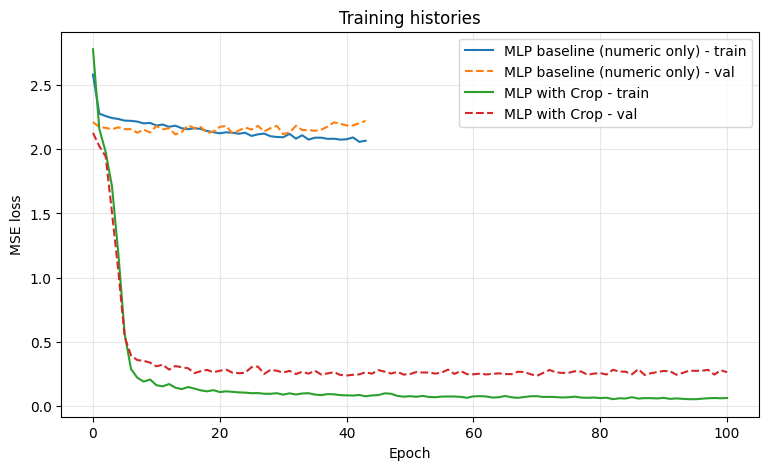

In [12]:
plt.figure(figsize=(9, 5))
for model_name, result in results_dict.items():
    plt.plot(result["history"]["train_loss"], label=f"{model_name} - train")
    plt.plot(result["history"]["val_loss"], linestyle="--", label=f"{model_name} - val")

plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training histories")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

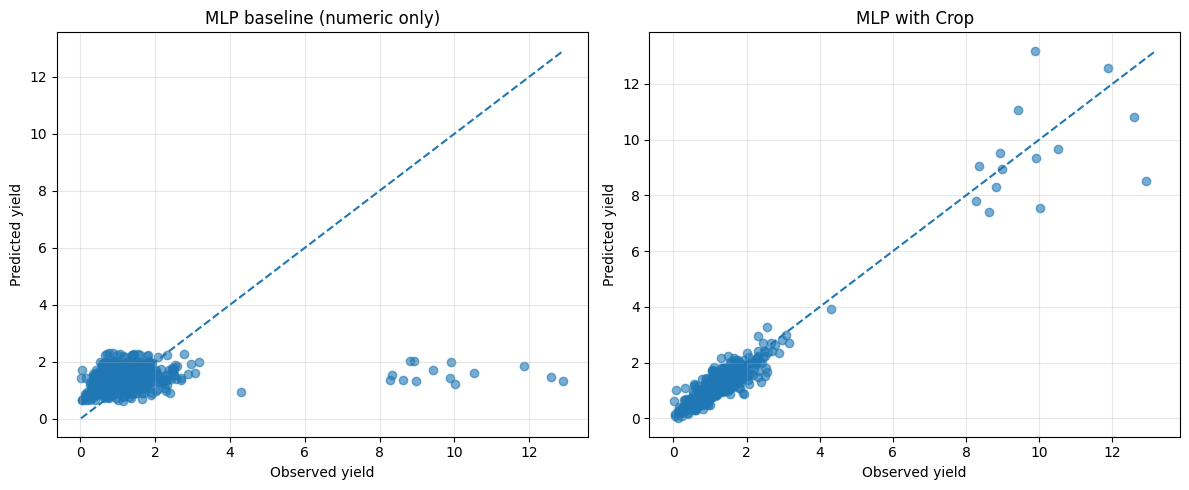

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=False, sharey=False)

for ax, (model_name, result) in zip(axes, results_dict.items()):
    y_true = result["outputs"]["test"]["y_true"]
    y_pred = result["outputs"]["test"]["y_pred"]

    ax.scatter(y_true, y_pred, alpha=0.6)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], linestyle="--")
    ax.set_title(model_name)
    ax.set_xlabel("Observed yield")
    ax.set_ylabel("Predicted yield")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

This notebook keeps the **same random split** and the **same MLP training setup** while changing only the feature set:

- **Baseline**: numeric-only inputs
- **New model**: numeric inputs + one-hot encoded `Crop`

The metrics tables above let you compare the new crop-aware MLP directly against the current baseline.
